# 📊 User Retention & Funnel Analysis

## 📌 Overview
This project analyzes user behavior to understand conversion across funnel stages, retention over time, and engagement patterns.

---

## 🎯 Problem Statement
Users:
- Sign up
- Login
- Create projects
- Invite users
- Upgrade plans

Goal:
- Analyze funnel conversion
- Measure retention
- Understand engagement

---

## 🛠️ Tools Used
- Python (Pandas, Seaborn, Matplotlib, Plotly)
- Jupyter Notebook

 2. IMPORT LIBRARIES (Code)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

3. LOAD DATA (Code)

In [2]:
users = pd.read_csv(r"C:\Users\KOMATIREDDY HARIKA\Desktop\retention_funnel_projects\data\users.csv")
events = pd.read_csv(r"C:\Users\KOMATIREDDY HARIKA\Desktop\retention_funnel_projects\data\events.csv")
funnel_df = pd.read_csv(r"C:\Users\KOMATIREDDY HARIKA\Desktop\retention_funnel_projects\dashboards\funnel.csv")

users.head()

,user_id,signup_date,channel
0,0,2026-04-14,referral
1,1,2026-04-12,referral
2,2,2026-04-01,ads
3,3,2026-04-09,organic
4,4,2026-02-19,organic


4. DATA CLEANING (Code)

In [3]:
users["signup_date"] = pd.to_datetime(users["signup_date"])
events["timestamp"] = pd.to_datetime(events["timestamp"])

5. FUNNEL ANALYSIS

In [4]:
stages = ["signup", "login", "create_project", "invite_user", "upgrade_plan"]

funnel_df["stage"] = pd.Categorical(funnel_df["stage"], categories=stages, ordered=True)
funnel_df = funnel_df.sort_values("stage")

fig = px.funnel(funnel_df, x="users", y="stage", title="User Funnel Analysis")
fig.show()

##  Funnel Insights
- Users drop gradually across stages
- Strong engagement in early stages
- Drop-off before upgrade stage

6. RETENTION ANALYSIS

In [6]:
users["cohort"] = users["signup_date"].dt.to_period("W").astype(str)

df = events.merge(users[["user_id","signup_date","cohort"]], on="user_id")

df["days_since_signup"] = (df["timestamp"] - df["signup_date"]).dt.days

def bucket(x):
    if x <= 0:
        return "Day 0"
    elif x <= 3:
        return "Day 1-3"
    elif x <= 7:
        return "Day 4-7"
    else:
        return "Day 8-30"

df["retention_day"] = df["days_since_signup"].apply(bucket)

retention_table = df.pivot_table(
    index="cohort",
    columns="retention_day",
    values="user_id",
    aggfunc="count",
    fill_value=0
)

# FIX + IMPROVE
order = ["Day 0", "Day 1-3", "Day 4-7", "Day 8-30"]
retention_table = retention_table.reindex(columns=order, fill_value=0)

retention_pct = retention_table.div(retention_table.iloc[:, 0], axis=0) * 100
retention_pct = retention_pct.round(1)

Heatmap Code

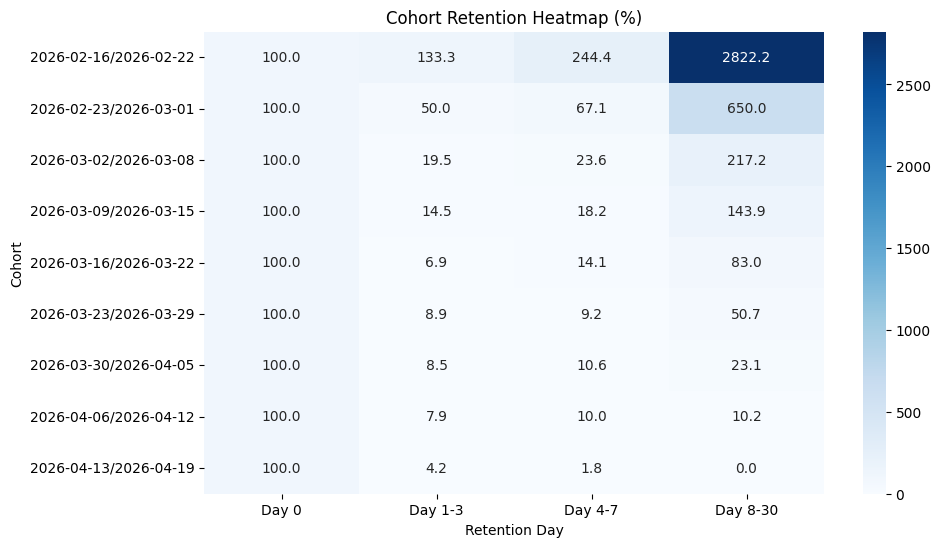

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(
    retention_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Cohort Retention Heatmap (%)")
plt.xlabel("Retention Day")
plt.ylabel("Cohort")

plt.show()

## 🔁 Retention Insights
- Highest engagement in Day 0–3
- Retention declines over time
- Early engagement is critical

7. EVENT DISTRIBUTION

In [8]:
event_counts = events["event_type"].value_counts()

fig = px.bar(
    x=event_counts.index,
    y=event_counts.values,
    labels={"x": "Event Type", "y": "Count"},
    title="Event Distribution"
)

fig.show()

## 📊 Event Insights
- Login and signup dominate activity
- Core features are actively used
- Upgrade events are lower

8. BUSINESS IMPACT

## 🚀 Business Impact
- Improve onboarding experience
- Encourage users to complete funnel steps
- Focus on retention after Day 3
- Optimize upgrade conversion

9. FINAL CONCLUSION

## 📌 Conclusion
This project highlights key drop-off points and retention trends.

Improving engagement and conversion strategies can significantly enhance user growth.